In [2]:
%load_ext autoreload
%autoreload 2

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import HTML, display
import os
from acpype.topol import ACTopol, MolTopol
import param_tool as pt
import py3Dmol
import MDAnalysis as mda

import nglview as nv
from parmed import amber, gromacs


IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

##  Генерация фаила топологии (.itp) при помощи библиотеки acpype
*Важный момент: acpype готов принимать в себя только единичные остатки аминокислот. При попытке параметризовать ди-/три-/поли-мер выводит следующие ошибки:*\
`ERROR: more than one residue detected '{'UNK', 'GLY'}'` \
`ERROR: verify your input file 'GRG_CITsmi.mol2'. Aborting ...`\
`ERROR: Only ONE Residue is allowed for ACPYPE to work`


In [3]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks


In [4]:
def path_dict(path_list):
    mol_dict = {} 
    if isinstance(path_list, str):
        name = os.path.basename(path_list).split('.')[0]
        mol_dict[name] = path_list
    if isinstance(path_list, list):
        for path in path_list:
            name = os.path.basename(path).split('.')[0]
            mol_dict[name] = path
    return mol_dict

### Наборы молекул для параметризации

#### SMI polymer

In [ ]:
mol_dict = path_dict(['moleculse/RA_CIT.smiles',
                      'moleculse/GRG_CIT.smiles',
                      'moleculse/GR_CIT.smiles'])
smi_dict = pt.read_file(mol_dict)
smi_dict

{'RA_CIT': '[H]N([H])C(=O)N([H])C([H])([H])C([H])([H])C([H])([H])[C@]([H])(C(=O)N([H])C([H])(C([O-])=O)C([H])([H])[H])[N+]([H])([H])[H]',
 'GRG_CIT': '[H]N([H])C(=O)N([H])C([H])([H])C([H])([H])C([H])([H])C([H])(N([H])C(=O)C([H])([H])[N+]([H])([H])[H])C(=O)N([H])C([H])([H])C([O-])=O',
 'GR_CIT': '[H]N([H])C(=O)N([H])C([H])([H])C([H])([H])C([H])([H])[C@]([H])(N([H])C(=O)C([H])([H])[N+]([H])([H])[H])C([O-])=O'}

#### MOL substructure

In [41]:
os.chdir('/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT')

## Использование acpype 

### SMI 

In [ ]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


In [ ]:
os.chdir('/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT')

In [ ]:
test_smi = pt.read_file(['moleculse/Lysine_1M_ACC.smiles',
              # 'moleculse/substructure/R_CIT.smiles',
              # 'moleculse/substructure/CR_CIT.smiles'
                        ])
test_chem = pt.smi_to_chem(test_smi, addH=False, sanitize=False)
IPythonConsole.drawOptions.addAtomIndices = True

In [ ]:
def renumber_atoms(mol):
    for atom in mol.GetAtoms():
        atom.SetProp('molAtomMapNumber', str(int(atom.GetIdx()) + 1))
    return mol

In [ ]:
renum_test_chem = {name: renumber_atoms(mol) for name, mol in test_chem.items()}

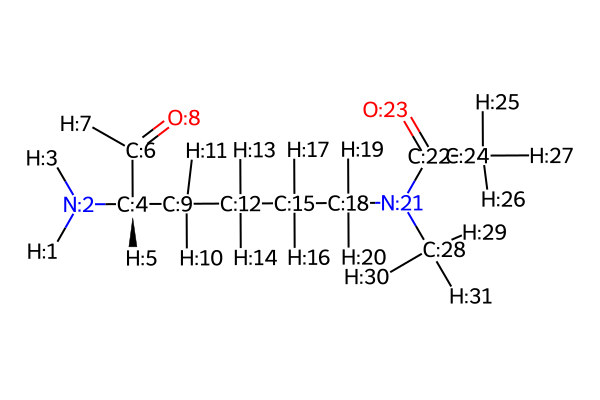

In [ ]:
IPythonConsole.drawOptions.addAtomIndices = False
renum_test_chem['Lysine_1M_ACC']

In [ ]:
chem_dict = pt.smi_to_chem(smi_dict, sanitize=False, addH=True)
chem_dict

NameError: name 'smi_dict' is not defined

In [ ]:
chem_dict['NR_CIT'].GetNumAtoms()

25

#### SMI ACTopol

In [ ]:
# os.makedirs('Acpype_data', exist_ok=True) 

In [ ]:
os.chdir('/home/_projects/2022_md_FRET_nv/param_R_CIT/Acpype_data')        

In [ ]:
molecule = ACTopol(inputFile=test_smi['Lysine_1M_ACC'], 
                   chargeType="gas", 
                   atomType='amber', 
                   outTopol='gmx',
                   basename=f'{full_mol_name}_smi', 
                   chargeVal=0, 
                      )

molecule.createACTopol()
molecule.createMolTopol()

==> ... charge set to 0
==> Executing Antechamber...
==> * Antechamber OK *
==> * Parmchk OK *
==> Executing Tleap...
==> * Tleap OK *
==> Removing temporary files...
==> Using OpenBabel v.3.1.0

==> Writing GROMACS files

==> Disambiguating lower and uppercase atomtypes in GMX top file, even if identical.

==> Writing GMX dihedrals for GMX 4.5 and higher.

==> Writing pickle file Lysine_1M_ACC_rn_smi.pkl
==> Removing temporary files...


### PDB

In [1]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks


In [5]:
path = 'Lysine_Cro/molecules/substructure/Lysine_Cro_rn_H_3D.pdb'
param_file = os.path.basename(path)
full_mol_name = param_file.split('.')[0]
print(full_mol_name)
# NR_CIT = RRR.select_atoms('resnum 1')
param_mol = mda.Universe(path)
nv.show_mdanalysis(param_mol)
# NR_CIT

Lysine_Cro_rn_H_3D


NGLWidget()

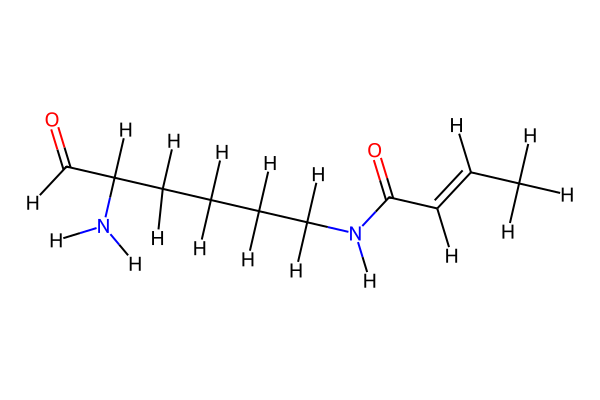

In [6]:
param_chem = pt.pdb_to_chem(path)
param_chem['Lysine_Cro_rn_H_3D']

In [7]:
param_file

'Lysine_1M_rn_H_3D.pdb'

In [8]:
# NR_CIT.write('moleculse/NR_CIT_pdb.pdb')

In [9]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


#### PDB ACTopol

In [10]:
# molecule = ACTopol(inputFile = f'../molecules/substructure/{param_file}', 
molecule = ACTopol(inputFile = f'../molecules/substructure/Lysine_Cro_rn_H_3D.pdb', 
                   
                   chargeType="gas",  # bcc
                   atomType='amber', 
                   outTopol='gmx', 
                   basename=full_mol_name, 
                   chargeVal=0, 
                   # debug=True
                   )
molecule.createACTopol()
molecule.createMolTopol()

==> ... charge set to 0
==> ... converting pdb input file to mol2 input file
==> * Babel OK *
==> Executing Antechamber...
==> * Antechamber OK *
==> * Parmchk OK *
==> Executing Tleap...
==> * Tleap OK *
==> Removing temporary files...
==> Using OpenBabel v.3.1.0

==> Writing GROMACS files

==> Disambiguating lower and uppercase atomtypes in GMX top file, even if identical.

==> Writing GMX dihedrals for GMX 4.5 and higher.

==> Writing pickle file Lysine_ACC_rn_H_3D.pkl
==> Removing temporary files...
